# **Multivariate Time Series Forecasting using Stacked LSTM (Multi-Factor Forecasting Intelligence System)**

### **Project Objective**

The objective of this project is to develop a **Multivariate Time-Series Forecasting System** using **Stacked LSTM Neural Networks** to predict future values based on multiple influencing factors.

In real-world scenarios, forecasting is rarely dependent on a single variable. This project focuses on leveraging multiple features to improve prediction accuracy by capturing complex relationships between variables.

The system is designed to:

- Predict **future values using multiple input variables**  
- Capture **temporal dependencies across multiple features**  
- Learn **complex interactions between variables**  
- Demonstrate the effectiveness of **stacked LSTM architectures for advanced forecasting**  

This project is highly applicable in:
- financial forecasting  
- energy demand prediction  
- supply chain optimization  
- business analytics  

### **Dataset Used**

This project utilizes multivariate time-series datasets containing multiple input features.

### **Dataset Sources**

- Multivariate Time-Series Datasets *(e.g., energy consumption, stock market data, or dataset used in your notebook)*  

### **Dataset Characteristics**

The dataset includes:

- **Time index**:
  - sequential timestamps  

- **Features**:
  - multiple input variables influencing the target  

- **Target variable**:
  - value to be predicted  

Key characteristics:
- multivariate time-series data  
- temporal dependencies  
- inter-variable relationships  

### **How Dataset is Used in the Project**

The dataset is processed through an advanced forecasting pipeline:

- **Data preprocessing**
  - normalization / scaling  
  - handling missing values  

- **Feature selection**
  - selecting relevant input variables  

- **Sequence generation**
  - converting data into supervised learning sequences  

- **Train-test split**
  - preserving temporal order  

- **Model training**
  - stacked LSTM learns multi-feature dependencies  
  - predicts future values  

The dataset enables the model to learn **complex temporal and feature interactions**, which are essential for accurate forecasting.





### **Import Core Libraries:**

In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Please run: pip install tensorflow")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### **Reproducibility Setup:**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Seed fixed at:", SEED)

Seed fixed at: 42


### **Create Project Folders:**

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_lstm_energy"
ARTIFACT_DIR = BASE_DIR / "artifacts_lstm_energy"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
for folder in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print(DATA_DIR)
print(ARTIFACT_DIR)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Multivariate Time Series Forecasting using Stacked LSTM\data_lstm_energy
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Multivariate Time Series Forecasting using Stacked LSTM\artifacts_lstm_energy


### **Load or Generate Multivariate Energy Dataset:**

In [4]:
def generate_energy_dataset(n_hours=24*365*2, seed=42):
    rng = np.random.default_rng(seed)
    ts = pd.date_range("2022-01-01", periods=n_hours, freq="h")

    hour = ts.hour
    dayofweek = ts.dayofweek
    month = ts.month
    dayofyear = ts.dayofyear

    temperature = 18 + 10*np.sin(2*np.pi*dayofyear/365) + 4*np.sin(2*np.pi*hour/24) + rng.normal(0, 1.5, n_hours)
    humidity = 55 + 15*np.cos(2*np.pi*dayofyear/365) - 6*np.sin(2*np.pi*hour/24) + rng.normal(0, 3.0, n_hours)
    weekend = (dayofweek >= 5).astype(int)
    business_activity = np.where((hour >= 8) & (hour <= 18), 1.0, 0.35)
    seasonality = 120 + 22*np.sin(2*np.pi*dayofyear/365) + 14*np.sin(2*np.pi*hour/24)

    load = (
        seasonality
        + 1.9 * temperature
        - 0.6 * humidity
        + 28 * business_activity
        - 10 * weekend
        + rng.normal(0, 5, n_hours)
    )

    df = pd.DataFrame({
        "timestamp": ts,
        "energy_load": load,
        "temperature": temperature,
        "humidity": humidity,
        "hour": hour,
        "dayofweek": dayofweek,
        "month": month,
        "weekend": weekend
    })
    return df, "synthetic_fallback"

def load_energy_data():
    local_candidates = [
        DATA_DIR / "hourly_energy.csv",
        DATA_DIR / "energy.csv",
        BASE_DIR / "hourly_energy.csv",
        BASE_DIR / "energy.csv"
    ]
    for path in local_candidates:
        if path.exists():
            try:
                df = pd.read_csv(path)
                return df, f"local_file:{path.name}"
            except Exception as e:
                print(f"Could not read {path}: {e}")
    return generate_energy_dataset(seed=SEED)

df, data_source = load_energy_data()
print("Data source used:", data_source)
print(df.shape)
df.head()

Data source used: synthetic_fallback
(17520, 8)


,timestamp,energy_load,temperature,humidity,hour,dayofweek,month,weekend
0,2022-01-01 00:00:00,110.150374,18.629209,71.972605,0,5,1,1
1,2022-01-01 01:00:00,112.691267,17.647434,68.126663,1,5,1,1
2,2022-01-01 02:00:00,123.434056,21.297810,68.208346,2,5,1,1
3,2022-01-01 03:00:00,128.994456,22.411408,67.277657,3,5,1,1
4,2022-01-01 04:00:00,122.708105,18.709682,65.844176,4,5,1,1


### **Standardize Timestamp Column:**

In [5]:
if "timestamp" not in df.columns:
    possible_ts_cols = [c for c in df.columns if "time" in c.lower() or "date" in c.lower()]
    if possible_ts_cols:
        df["timestamp"] = pd.to_datetime(df[possible_ts_cols[0]])
    else:
        df["timestamp"] = pd.date_range("2022-01-01", periods=len(df), freq="H")
else:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)
df.head()

,timestamp,energy_load,temperature,humidity,hour,dayofweek,month,weekend
0,2022-01-01 00:00:00,110.150374,18.629209,71.972605,0,5,1,1
1,2022-01-01 01:00:00,112.691267,17.647434,68.126663,1,5,1,1
2,2022-01-01 02:00:00,123.434056,21.297810,68.208346,2,5,1,1
3,2022-01-01 03:00:00,128.994456,22.411408,67.277657,3,5,1,1
4,2022-01-01 04:00:00,122.708105,18.709682,65.844176,4,5,1,1


### **Initial Inspection:**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    17520 non-null  datetime64[us]
 1   energy_load  17520 non-null  float64       
 2   temperature  17520 non-null  float64       
 3   humidity     17520 non-null  float64       
 4   hour         17520 non-null  int32         
 5   dayofweek    17520 non-null  int32         
 6   month        17520 non-null  int32         
 7   weekend      17520 non-null  int32         
dtypes: datetime64[us](1), float64(3), int32(4)
memory usage: 821.4 KB


### **Missing Value Check:**

In [7]:
missing_df = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing_df["missing_pct"] = (missing_df["missing_count"] / len(df) * 100).round(3)
missing_df

,missing_count,missing_pct
timestamp,0,0.0
energy_load,0,0.0
temperature,0,0.0
humidity,0,0.0
hour,0,0.0
dayofweek,0,0.0
month,0,0.0
weekend,0,0.0


### **Basic Summary Statistics:**

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,17520,2022-12-31 23:30:00,2022-01-01 00:00:00,2022-07-02 11:45:00,2022-12-31 23:30:00,2023-07-02 11:15:00,2023-12-31 23:00:00,NaN
energy_load,17520.0,136.346298,44.364793,109.432068,136.171044,163.92695,226.553242,35.49786
temperature,17520.0,17.994617,0.285365,11.572555,17.983746,24.424831,36.218881,7.742916
humidity,17520.0,55.057049,25.21106,45.321231,55.030041,64.792155,85.464645,11.823452
hour,17520.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922384
dayofweek,17520.0,3.006849,0.0,1.0,3.0,5.0,6.0,2.001757
month,17520.0,6.526027,1.0,4.0,7.0,10.0,12.0,3.44795
weekend,17520.0,0.287671,0.0,0.0,0.0,1.0,1.0,0.45269


### **Create Calendar Features:**

In [9]:
df["hour"] = df["timestamp"].dt.hour if "hour" not in df.columns else df["hour"]
df["dayofweek"] = df["timestamp"].dt.dayofweek if "dayofweek" not in df.columns else df["dayofweek"]
df["month"] = df["timestamp"].dt.month if "month" not in df.columns else df["month"]
df["weekend"] = (df["dayofweek"] >= 5).astype(int) if "weekend" not in df.columns else df["weekend"]
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df.head()

,timestamp,energy_load,temperature,humidity,hour,dayofweek,month,weekend,hour_sin,hour_cos,dow_sin,dow_cos
0,2022-01-01 00:00:00,110.150374,18.629209,71.972605,0,5,1,1,0.000000,1.000000,-0.974928,-0.222521
1,2022-01-01 01:00:00,112.691267,17.647434,68.126663,1,5,1,1,0.258819,0.965926,-0.974928,-0.222521
2,2022-01-01 02:00:00,123.434056,21.297810,68.208346,2,5,1,1,0.500000,0.866025,-0.974928,-0.222521
3,2022-01-01 03:00:00,128.994456,22.411408,67.277657,3,5,1,1,0.707107,0.707107,-0.974928,-0.222521
4,2022-01-01 04:00:00,122.708105,18.709682,65.844176,4,5,1,1,0.866025,0.500000,-0.974928,-0.222521


### **Plot Energy Load Over Time:**

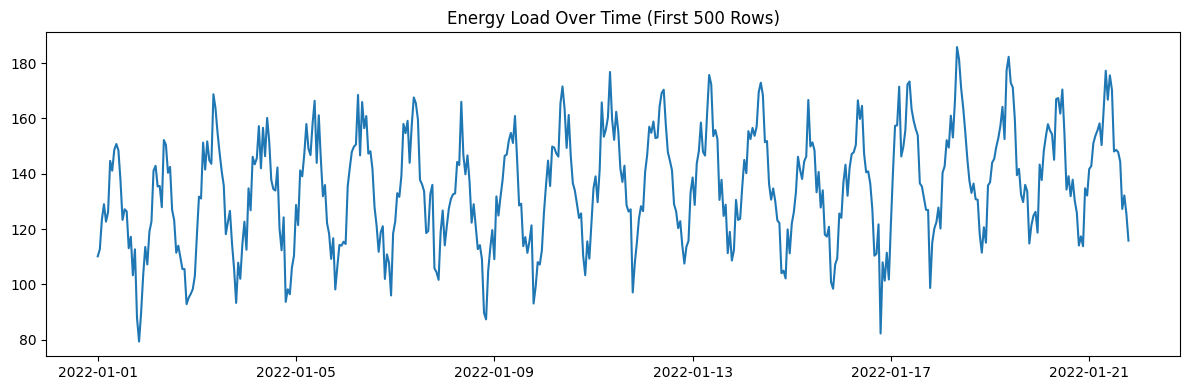

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"].iloc[:500], df["energy_load"].iloc[:500])
plt.title("Energy Load Over Time (First 500 Rows)")
plt.tight_layout()
plt.show()

### **Plot Temperature Over Time:**

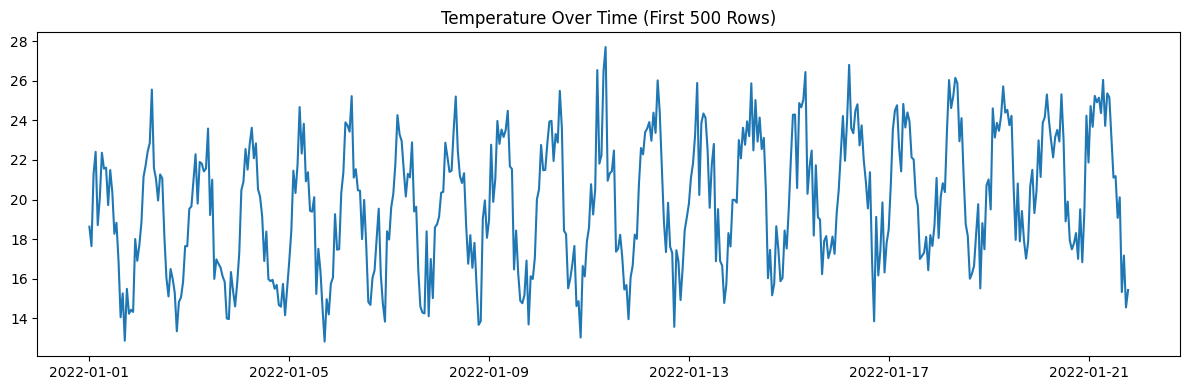

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"].iloc[:500], df["temperature"].iloc[:500])
plt.title("Temperature Over Time (First 500 Rows)")
plt.tight_layout()
plt.show()

### **Plot Humidity Over Time:**

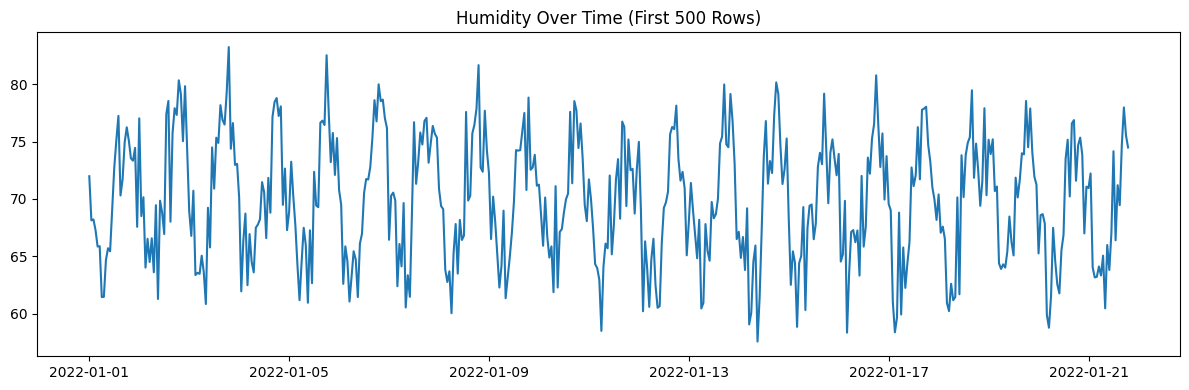

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"].iloc[:500], df["humidity"].iloc[:500])
plt.title("Humidity Over Time (First 500 Rows)")
plt.tight_layout()
plt.show()

### **Hourly Average Load:**

In [13]:
hourly_load = df.groupby("hour")["energy_load"].mean()
hourly_load

hour
0     128.095172
1     134.498355
2     140.409059
3     145.677937
4     149.988909
5     152.457125
6     153.271694
7     152.177499
8     168.086072
9     164.240663
10    158.613430
11    152.348731
12    146.139918
13    139.870154
14    133.393906
15    128.432142
16    124.506833
17    122.146680
18    121.197085
19    103.603808
20    106.118467
21    110.240467
22    115.302582
23    121.494454
Name: energy_load, dtype: float64

### **Plot Hourly Average Load:**

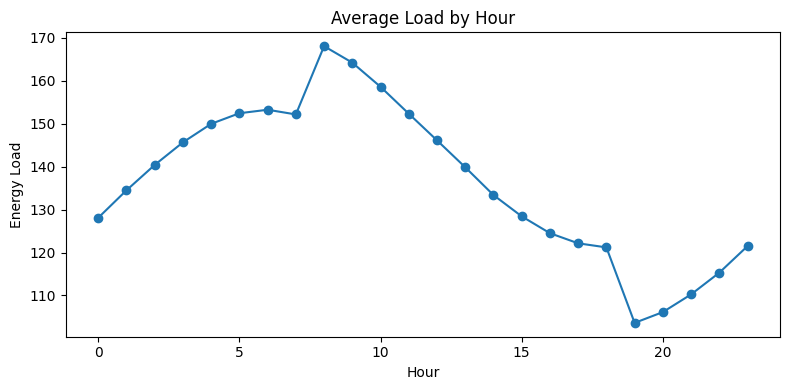

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(hourly_load.index, hourly_load.values, marker="o")
plt.title("Average Load by Hour")
plt.xlabel("Hour")
plt.ylabel("Energy Load")
plt.tight_layout()
plt.show()

### **Day-of-Week Average Load:**

In [15]:
dow_load = df.groupby("dayofweek")["energy_load"].mean()
dow_load

dayofweek
0    139.343852
1    139.290296
2    139.158931
3    139.446315
4    139.051871
5    129.118852
6    129.152629
Name: energy_load, dtype: float64

### **Plot Day-of-Week Average Load:**

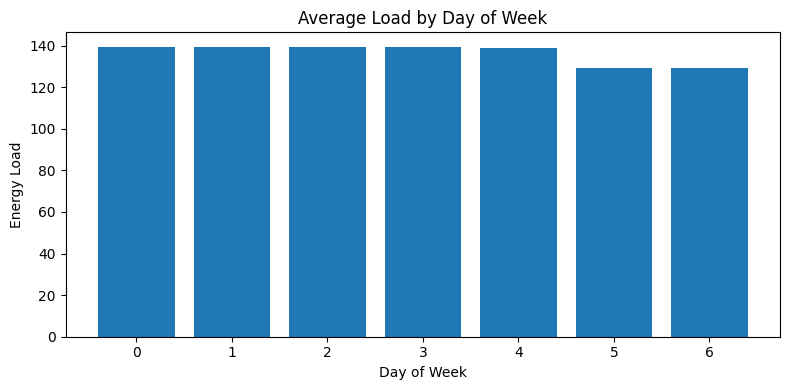

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(dow_load.index.astype(str), dow_load.values)
plt.title("Average Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Energy Load")
plt.tight_layout()
plt.show()

### **Correlation Analysis:**

In [17]:
corr_df = df[["energy_load","temperature","humidity","hour","dayofweek","month","weekend","hour_sin","hour_cos","dow_sin","dow_cos"]].corr()
corr_df

,energy_load,temperature,humidity,hour,dayofweek,month,weekend,hour_sin,hour_cos,dow_sin,dow_cos
energy_load,1.000000,0.920243,-0.330875,-3.381668e-01,-1.029988e-01,-6.361190e-01,-1.290883e-01,4.418006e-01,-2.214941e-01,1.021297e-01,-2.231218e-02
temperature,0.920243,1.000000,-0.131480,-2.851206e-01,-1.395094e-03,-7.086630e-01,-7.221505e-04,3.658660e-01,3.804844e-04,1.712833e-03,7.613422e-04
humidity,-0.330875,-0.131480,1.000000,2.763673e-01,4.007287e-03,9.342272e-04,4.448411e-03,-3.563559e-01,2.205765e-03,-2.875933e-03,1.081102e-03
hour,-0.338167,-0.285121,0.276367,1.000000e+00,-4.595296e-18,6.167867e-16,4.432869e-18,-7.759122e-01,-1.021508e-01,-1.268811e-17,1.673959e-17
dayofweek,-0.102999,-0.001395,0.004007,-4.595296e-18,1.000000e+00,6.821933e-03,7.915121e-01,-1.226712e-18,-1.611739e-19,-7.351123e-01,-3.511789e-01
month,-0.636119,-0.708663,0.000934,6.167867e-16,6.821933e-03,1.000000e+00,4.689018e-04,-1.705087e-18,1.118703e-17,-3.192453e-03,-1.311378e-02
weekend,-0.129088,-0.000722,0.004448,4.432869e-18,7.915121e-01,4.689018e-04,1.000000e+00,2.024259e-18,-1.583772e-18,-7.866515e-01,1.798236e-01
hour_sin,0.441801,0.365866,-0.356356,-7.759122e-01,-1.226712e-18,-1.705087e-18,2.024259e-18,1.000000e+00,-2.566440e-17,-8.453294e-19,2.111811e-18
hour_cos,-0.221494,0.000380,0.002206,-1.021508e-01,-1.611739e-19,1.118703e-17,-1.583772e-18,-2.566440e-17,1.000000e+00,-1.051121e-18,7.863799e-19
dow_sin,0.102130,0.001713,-0.002876,-1.268811e-17,-7.351123e-01,-3.192453e-03,-7.866515e-01,-8.453294e-19,-1.051121e-18,1.000000e+00,-7.385181e-04


### **Plot Correlation Heatmap:**

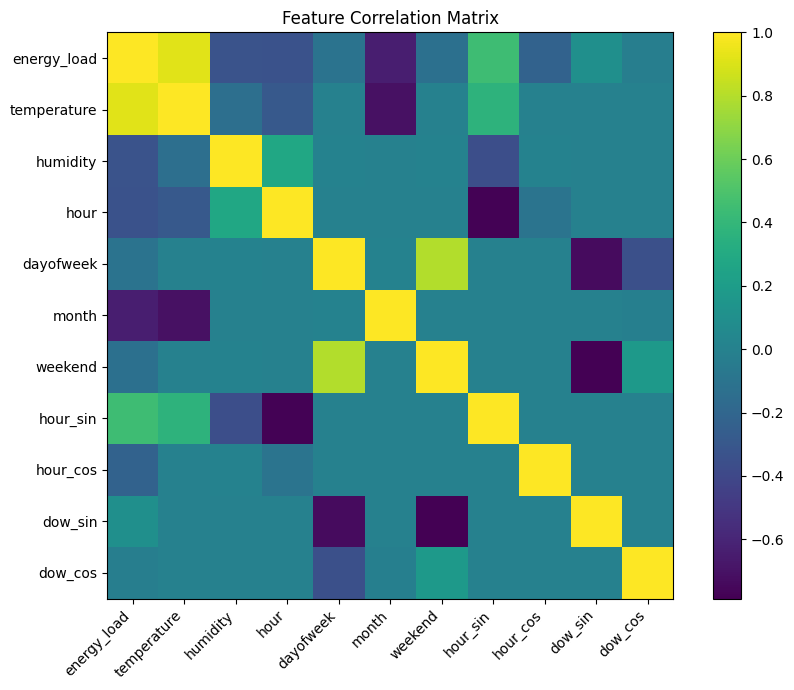

In [18]:
plt.figure(figsize=(9, 7))
plt.imshow(corr_df, interpolation="nearest")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_df.columns)), corr_df.columns)
plt.title("Feature Correlation Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

### **Select Forecasting Features:**

In [19]:
target_col = "energy_load"
feature_cols = ["energy_load","temperature","humidity","hour_sin","hour_cos","dow_sin","dow_cos","weekend"]
feature_cols

['energy_load',
 'temperature',
 'humidity',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'weekend']

### **Train / Validation / Test Split:**

In [20]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(train_df.shape, val_df.shape, test_df.shape)

(12264, 12) (2628, 12) (2628, 12)


### **Scale Features:**

In [21]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(train_df[feature_cols])
val_features_scaled = feature_scaler.transform(val_df[feature_cols])
test_features_scaled = feature_scaler.transform(test_df[feature_cols])

train_target_scaled = target_scaler.fit_transform(train_df[[target_col]])
val_target_scaled = target_scaler.transform(val_df[[target_col]])
test_target_scaled = target_scaler.transform(test_df[[target_col]])

print(train_features_scaled.shape, train_target_scaled.shape)

(12264, 8) (12264, 1)


### **Define Sequence Builder:**

In [22]:
def build_sequences(features, target, seq_len=24):
    X, y = [], []
    for i in range(seq_len, len(features)):
        X.append(features[i-seq_len:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

### **Build Sequences:**

In [23]:
SEQ_LEN = 24
X_train, y_train = build_sequences(train_features_scaled, train_target_scaled, seq_len=SEQ_LEN)
X_val, y_val = build_sequences(val_features_scaled, val_target_scaled, seq_len=SEQ_LEN)
X_test, y_test = build_sequences(test_features_scaled, test_target_scaled, seq_len=SEQ_LEN)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(12240, 24, 8) (12240,)
(2604, 24, 8) (2604,)
(2604, 24, 8) (2604,)


### **Inspect One Sequence Sample:**

In [24]:
print("Sequence shape:", X_train[0].shape)
pd.DataFrame(X_train[0], columns=feature_cols).head()

Sequence shape: (24, 8)


,energy_load,temperature,humidity,hour_sin,hour_cos,dow_sin,dow_cos,weekend
0,-0.970334,-0.184696,1.379914,2.601458e-17,1.414214,-1.378756,-0.314692,1.581139
1,-0.897924,-0.313061,1.046508,3.660254e-01,1.366025,-1.378756,-0.314692,1.581139
2,-0.591776,0.164217,1.053590,7.071068e-01,1.224745,-1.378756,-0.314692,1.581139
3,-0.433315,0.309818,0.972908,1.000000e+00,1.000000,-1.378756,-0.314692,1.581139
4,-0.612464,-0.174175,0.848639,1.224745e+00,0.707107,-1.378756,-0.314692,1.581139


### **Build Naive Baseline Predictions:**

In [25]:
baseline_val_pred_scaled = X_val[:, -1, 0]
baseline_test_pred_scaled = X_test[:, -1, 0]

print(baseline_val_pred_scaled.shape, baseline_test_pred_scaled.shape)

(2604,) (2604,)


### **Inverse Transform Helper:**

In [26]:
def inverse_target(arr_1d):
    return target_scaler.inverse_transform(arr_1d.reshape(-1, 1)).reshape(-1)

### **Convert Baseline Predictions Back to Original Scale:**

In [27]:
y_val_actual = inverse_target(y_val)
y_test_actual = inverse_target(y_test)

baseline_val_pred = inverse_target(baseline_val_pred_scaled)
baseline_test_pred = inverse_target(baseline_test_pred_scaled)

### **Baseline Metrics:**

In [28]:
baseline_val_mae = mean_absolute_error(y_val_actual, baseline_val_pred)
baseline_val_rmse = mean_squared_error(y_val_actual, baseline_val_pred) ** 0.5
baseline_test_mae = mean_absolute_error(y_test_actual, baseline_test_pred)
baseline_test_rmse = mean_squared_error(y_test_actual, baseline_test_pred) ** 0.5

print("Baseline validation MAE:", round(float(baseline_val_mae), 4))
print("Baseline validation RMSE:", round(float(baseline_val_rmse), 4))
print("Baseline test MAE:", round(float(baseline_test_mae), 4))
print("Baseline test RMSE:", round(float(baseline_test_rmse), 4))

Baseline validation MAE: 8.5929
Baseline validation RMSE: 10.753
Baseline test MAE: 8.5287
Baseline test RMSE: 10.8063


### **Build Stacked LSTM Model:**

In [29]:
def build_stacked_lstm(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(16),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

### **Instantiate Stacked LSTM:**

In [30]:
lstm_model = build_stacked_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 24, 64)              │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 24, 32)              │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,529 (134.88 KB)

 Trainable params: 34,529 (134.88 KB)

 Non-trainable params: 0 (0.00 B)

### **Training Callbacks:**

In [31]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

### **Train Stacked LSTM:**

In [32]:
history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1320 - mae: 0.2569 - val_loss: 0.0490 - val_mae: 0.1765 - learning_rate: 0.0010
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0509 - mae: 0.1795 - val_loss: 0.0492 - val_mae: 0.1773 - learning_rate: 0.0010
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0475 - mae: 0.1734 - val_loss: 0.0426 - val_mae: 0.1645 - learning_rate: 0.0010
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0453 - mae: 0.1694 - val_loss: 0.0413 - val_mae: 0.1618 - learning_rate: 0.0010
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0440 - mae: 0.1666 - val_loss: 0.0405 - val_mae: 0.1603 - learning_rate: 0.0010
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0429 - mae: 0.1649 - val_loss: 0.0388 - val_mae: 0.1568 - learning_rate: 0.0010
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0418 - mae: 0.1632 - val_loss: 0.0390 - val_mae: 0.1575 - learning_rate: 0.0010

### **Plot Training vs Validation Loss:**

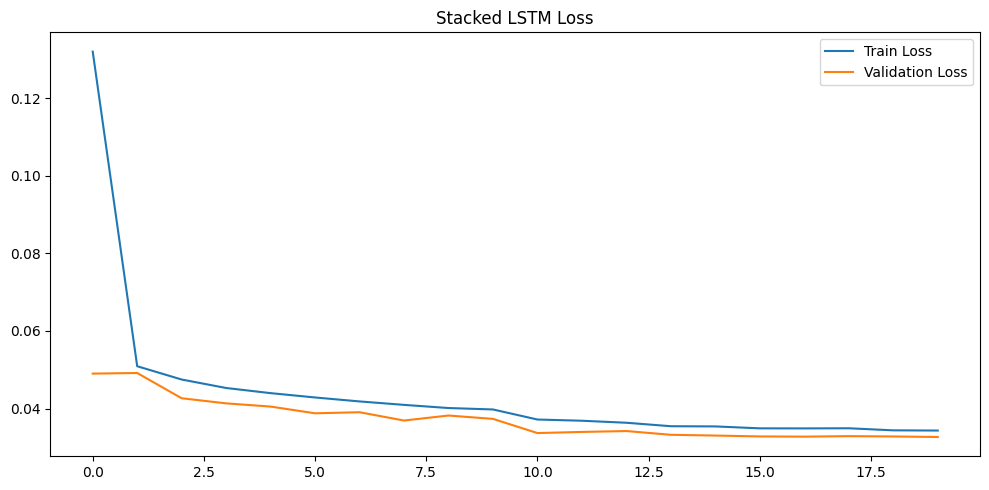

In [33]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Stacked LSTM Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Training vs Validation MAE:**

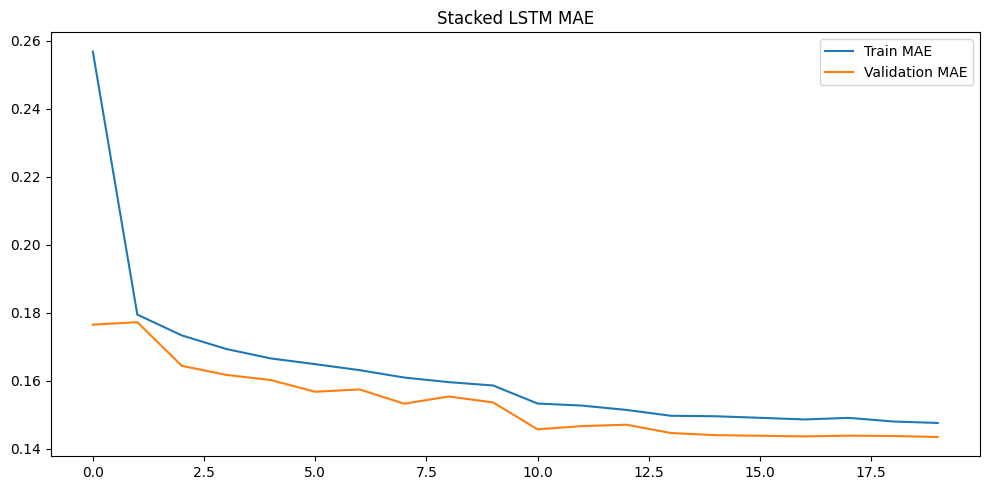

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["mae"], label="Train MAE")
plt.plot(history_df["val_mae"], label="Validation MAE")
plt.title("Stacked LSTM MAE")
plt.legend()
plt.tight_layout()
plt.show()

### **Predict Validation and Test Sets:**

In [35]:
val_pred_scaled = lstm_model.predict(X_val, verbose=0).reshape(-1)
test_pred_scaled = lstm_model.predict(X_test, verbose=0).reshape(-1)

val_pred = inverse_target(val_pred_scaled)
test_pred = inverse_target(test_pred_scaled)

### **Validation Metrics:**

In [36]:
val_mae = mean_absolute_error(y_val_actual, val_pred)
val_rmse = mean_squared_error(y_val_actual, val_pred) ** 0.5
val_r2 = r2_score(y_val_actual, val_pred)

print("Validation MAE:", round(float(val_mae), 4))
print("Validation RMSE:", round(float(val_rmse), 4))
print("Validation R2:", round(float(val_r2), 4))

Validation MAE: 5.036
Validation RMSE: 6.3412
Validation R2: 0.9496


### **Test Metrics:**

In [37]:
test_mae = mean_absolute_error(y_test_actual, test_pred)
test_rmse = mean_squared_error(y_test_actual, test_pred) ** 0.5
test_r2 = r2_score(y_test_actual, test_pred)

print("Test MAE:", round(float(test_mae), 4))
print("Test RMSE:", round(float(test_rmse), 4))
print("Test R2:", round(float(test_r2), 4))

Test MAE: 5.0277
Test RMSE: 6.3226
Test R2: 0.9164


### **Compare Baseline vs LSTM:**

In [38]:
comparison_df = pd.DataFrame({
    "Model": ["Naive Baseline", "Stacked LSTM"],
    "Validation_MAE": [baseline_val_mae, val_mae],
    "Validation_RMSE": [baseline_val_rmse, val_rmse],
    "Test_MAE": [baseline_test_mae, test_mae],
    "Test_RMSE": [baseline_test_rmse, test_rmse]
})
comparison_df

,Model,Validation_MAE,Validation_RMSE,Test_MAE,Test_RMSE
0,Naive Baseline,8.592921,10.752962,8.528700,10.806276
1,Stacked LSTM,5.035973,6.341225,5.027741,6.322647


### **Plot Actual vs Predicted (Validation):**

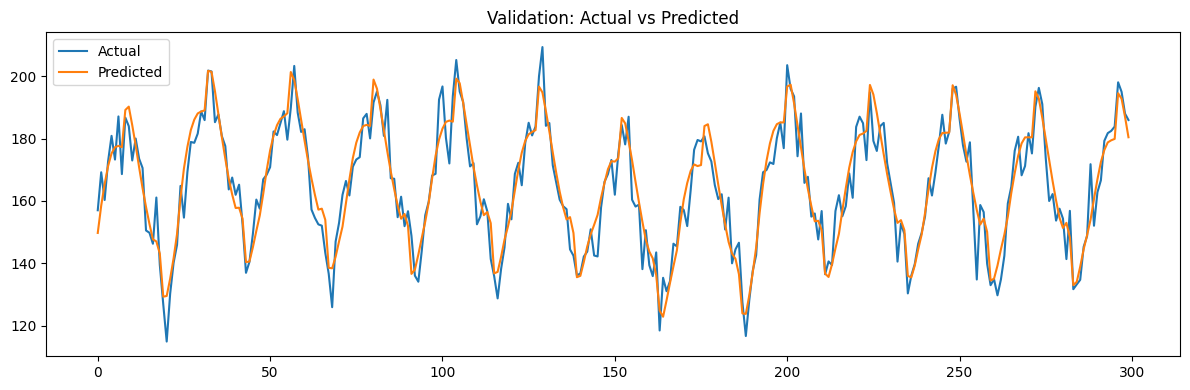

In [39]:
plt.figure(figsize=(12, 4))
plt.plot(y_val_actual[:300], label="Actual")
plt.plot(val_pred[:300], label="Predicted")
plt.title("Validation: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Actual vs Predicted (Test):**

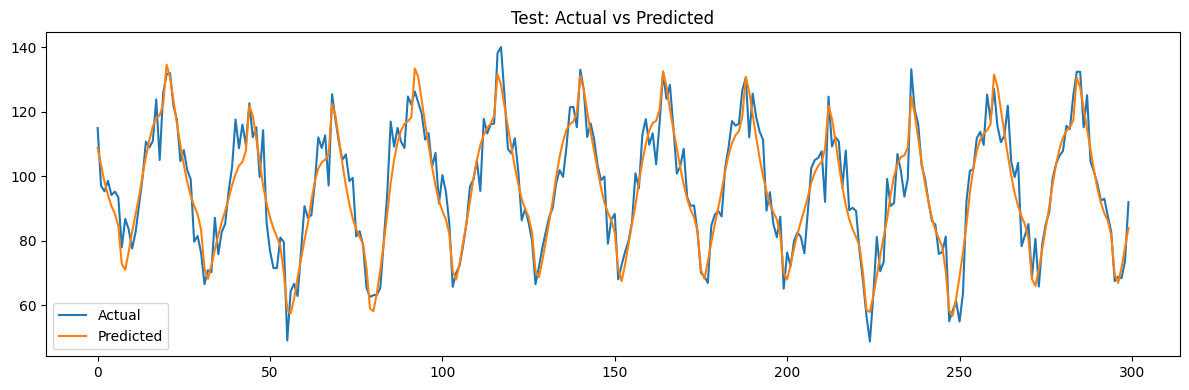

In [40]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual[:300], label="Actual")
plt.plot(test_pred[:300], label="Predicted")
plt.title("Test: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

### **Residual Analysis:**

In [41]:
residuals = y_test_actual - test_pred
pd.Series(residuals).describe()

count    2604.000000
mean        0.623819
std         6.293006
min       -18.689679
25%        -3.639518
50%         0.683453
75%         4.892157
max        25.580955
dtype: float64

### **Plot Residual Distribution:**

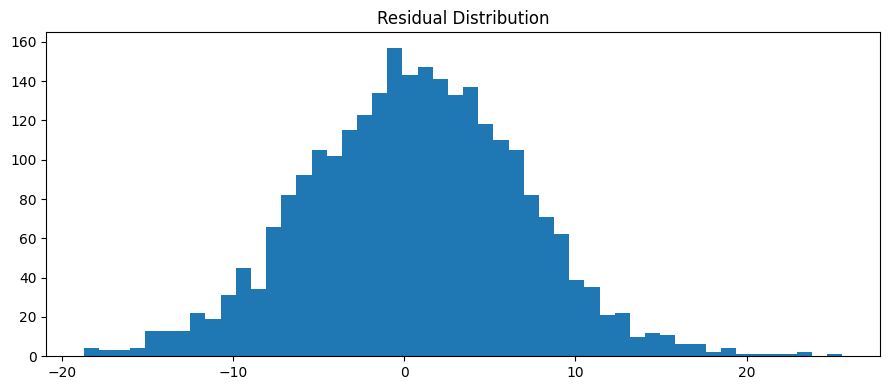

In [42]:
plt.figure(figsize=(9, 4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

### **Plot Residuals Over Time:**

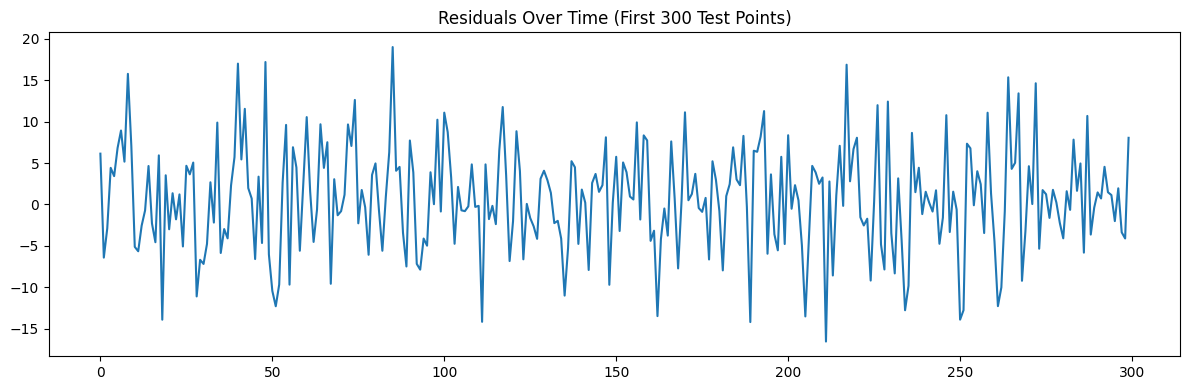

In [43]:
plt.figure(figsize=(12, 4))
plt.plot(residuals[:300])
plt.title("Residuals Over Time (First 300 Test Points)")
plt.tight_layout()
plt.show()

### **Error by Hour of Day:**

In [44]:
test_hours = test_df["hour"].iloc[SEQ_LEN:].reset_index(drop=True)
hour_error_df = pd.DataFrame({"hour": test_hours, "abs_error": np.abs(residuals)})
hour_error_summary = hour_error_df.groupby("hour")["abs_error"].mean()
hour_error_summary

hour
0     6.037631
1     5.856155
2     4.673588
3     5.290007
4     4.269480
5     5.037345
6     5.140882
7     5.140331
8     4.767927
9     5.243760
10    4.753514
11    5.209560
12    5.149275
13    5.012649
14    4.860019
15    5.322526
16    4.637117
17    4.501600
18    5.607859
19    4.609220
20    5.773064
21    4.680131
22    5.151959
23    3.950167
Name: abs_error, dtype: float64

### **Plot Error by Hour of Day:**

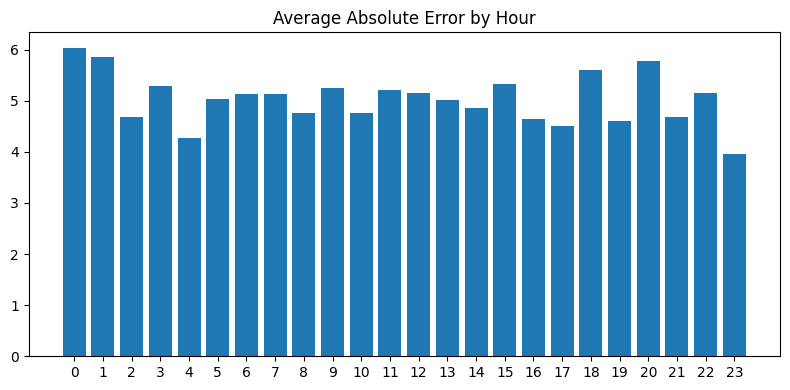

In [45]:
plt.figure(figsize=(8, 4))
plt.bar(hour_error_summary.index.astype(str), hour_error_summary.values)
plt.title("Average Absolute Error by Hour")
plt.tight_layout()
plt.show()

### **Best Forecast Examples:**

In [46]:
best_idx = np.argsort(np.abs(residuals))[:10]
best_idx[:10]

array([1587, 1390, 1258, 2417, 1272,  832, 2068,   97, 1241, 1763],
      dtype=int64)

### **Worst Forecast Examples:**

In [47]:
worst_idx = np.argsort(np.abs(residuals))[-10:]
worst_idx[:10]

array([2105,   85, 1445,  990, 1033,  588, 1448, 2550, 1515, 1933],
      dtype=int64)

### **Forecast Sample Table:**

In [48]:
sample_df = pd.DataFrame({
    "actual": y_test_actual[:20],
    "predicted": test_pred[:20],
    "residual": residuals[:20]
})
sample_df

,actual,predicted,residual
0,114.910047,108.774109,6.135939
1,96.915489,103.335838,-6.420349
2,95.288606,98.171379,-2.882774
3,98.536702,94.114792,4.421910
4,94.121101,90.701447,3.419655
5,95.185022,88.365082,6.819940
6,93.436638,84.509056,8.927582
7,77.917397,72.748459,5.168939
8,86.707995,70.933403,15.774592
9,83.541802,76.475067,7.066735


### **Save Model Artifacts:**

In [49]:
model_path = MODEL_DIR / "stacked_lstm_energy.keras"
scaler_path = MODEL_DIR / "scalers.json"

lstm_model.save(model_path)

scaler_meta = {
    "feature_mean": feature_scaler.mean_.tolist(),
    "feature_scale": feature_scaler.scale_.tolist(),
    "target_mean": target_scaler.mean_.tolist(),
    "target_scale": target_scaler.scale_.tolist(),
    "feature_cols": feature_cols,
    "seq_len": SEQ_LEN
}
with open(scaler_path, "w") as f:
    json.dump(scaler_meta, f, indent=4)

print(model_path)
print(scaler_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Multivariate Time Series Forecasting using Stacked LSTM\artifacts_lstm_energy\models\stacked_lstm_energy.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Multivariate Time Series Forecasting using Stacked LSTM\artifacts_lstm_energy\models\scalers.json


### **Reload Model for Inference Check:**

In [50]:
reloaded_model = tf.keras.models.load_model(model_path)
sample_pred = reloaded_model.predict(X_test[:5], verbose=0)
sample_pred.shape

(5, 1)

### **Final Metrics Summary Table:**

In [51]:
summary_table = pd.DataFrame({
    "Metric": ["Baseline Test MAE","Baseline Test RMSE","LSTM Test MAE","LSTM Test RMSE","LSTM Test R2"],
    "Value": [baseline_test_mae, baseline_test_rmse, test_mae, test_rmse, test_r2]
})
summary_table

,Metric,Value
0,Baseline Test MAE,8.528700
1,Baseline Test RMSE,10.806276
2,LSTM Test MAE,5.027741
3,LSTM Test RMSE,6.322647
4,LSTM Test R2,0.916397


### **Project Summary**

This project presents a complete implementation of a **Multivariate Time-Series Forecasting System using Stacked LSTM Networks**, focusing on predicting future values based on multiple variables.

The workflow begins with preprocessing time-series data, including normalization and sequence preparation.

The core of the system is a **Stacked LSTM Model**, which consists of:

### **1. Sequence Input Layer**

- Accepts multivariate time-series sequences  

### **2. Stacked LSTM Layers**

- Multiple LSTM layers stacked  
- Capture hierarchical temporal features  

### **3. Dense Output Layer**

- Predicts future target values  

The model learns:
- temporal dependencies  
- inter-variable relationships  
- complex patterns across features  

A key strength of this project is:

- **Multivariate modeling**
  - considers multiple influencing factors  

- **Deep architecture**
  - captures hierarchical patterns  

Evaluation is performed using:

- Mean Squared Error (MSE)  
- Root Mean Squared Error (RMSE)  

The system can be used in real-world applications to:

- forecast demand  
- analyze trends  
- support decision-making  

Overall, this project demonstrates advanced AI capabilities and showcases the ability to build **multi-factor forecasting systems using deep learning**.

### **Key Highlights**

- Built a **Multivariate Time-Series Forecasting system using Stacked LSTM**, targeting advanced forecasting applications.

- Addressed complex problem:
  - forecasting using multiple variables  

- Utilized dataset with:
  - multivariate time-series data  

- Implemented a complete **data preprocessing pipeline**, including:
  - normalization  
  - sequence generation  

- Leveraged **Stacked LSTM architecture**, enabling:
  - deep temporal modeling  

- Designed a **forecasting system**, enabling:
  - prediction using multiple features  

- Developed a **multi-factor prediction model**, capable of:
  - capturing feature interactions  
  - improving accuracy  

- Evaluated model performance using:
  - MSE, RMSE  

- Enabled **real-world applications**, including:
  - finance  
  - energy forecasting  
  - business analytics  

- Designed for **deployment scenarios**, including:
  - forecasting dashboards  
  - decision-support systems  

- Demonstrates strong expertise in:
  - **time-series forecasting**  
  - **deep learning (LSTM)**  
  - **multivariate analysis**